# 3-Pulse Mach-Zehnder Interferometer with Temperature — New Pulse API

Replicates `mach_zehnder_with_temperature.ipynb` using the new event-based pulse sequence API
(`build_mach_zehnder_pulse_sequence` + `calculate_excited_fraction_for_pulse_sequence`).

Demonstrates a $\pi/2 - \pi - \pi/2$ Mach-Zehnder atom interferometer sequence.

Pulse phases: $0$, $\phi$, $4\phi$ respectively, with $\phi$ scanned from $0$ to $2\pi$.

Repeat with detunings drawn from a distribution based on a Maxwell-Boltzmann distribution of velocities at $T = 200\,\mathrm{nK}$.

A final comparison cell verifies numerical equivalence with the old low-level implementation.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

import lmt_sim.version_info as vs

from lmt_sim.lmt_sequence import (
    build_mach_zehnder_pulse_sequence,
    calculate_excited_fraction_for_pulse_sequence,
)
from lmt_sim.lmt_simulation import (
    RECOIL_FREQUENCY_HZ,
    RABI_FREQ,
)

%matplotlib inline

In [3]:
# np.random.seed(42)

T_FREE = 200e-6  # Free evolution time between pulses

MASS_ATOM = constants.atomic_mass * 87

# Draw velocities from 1D Maxwell-Boltzmann distribution at T
# 1D MB is a Gaussian with sigma_v = sqrt(k_B T / m)
N_ATOMS = 200
TEMPERATURE = 200e-9

sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0, sigma_v, size=N_ATOMS)
phi_values = np.linspace(0, 2 * np.pi, 101)

In [4]:
from tqdm import tqdm


def calc_mz_excitation_pulse_api(
    phi,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    pulse_sequence = build_mach_zehnder_pulse_sequence(
        phi=phi,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=time_between_pulses,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    return calculate_excited_fraction_for_pulse_sequence(
        pulse_sequence,
        velocity=(0.0, 0.0, initial_velocity_z),
    )


# Simulate for each atom velocity
excitation_curves = np.empty((N_ATOMS, len(phi_values)))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    excitation_fractions = np.empty_like(phi_values)

    for ind_phi, phi in enumerate(phi_values):
        excitation_fractions[ind_phi] = calc_mz_excitation_pulse_api(
            phi,
            initial_velocity_z=velocity,
            time_between_pulses=T_FREE,
        )

        if excitation_fractions[ind_phi] < 0 or excitation_fractions[ind_phi] > 1:
            print(
                f"Warning: Unphysical excitation fraction {excitation_fractions[ind_phi]:.3f} "
                f"for velocity {velocity:.2f} m/s, phi={phi:.2f}"
            )

    excitation_curves[ind_atom, :] = excitation_fractions

mean_excitation = np.mean(excitation_curves, axis=0)
std_excitation = np.std(excitation_curves, axis=0)

Simulating atoms: 100%|██████████| 200/200 [00:23<00:00,  8.58it/s]


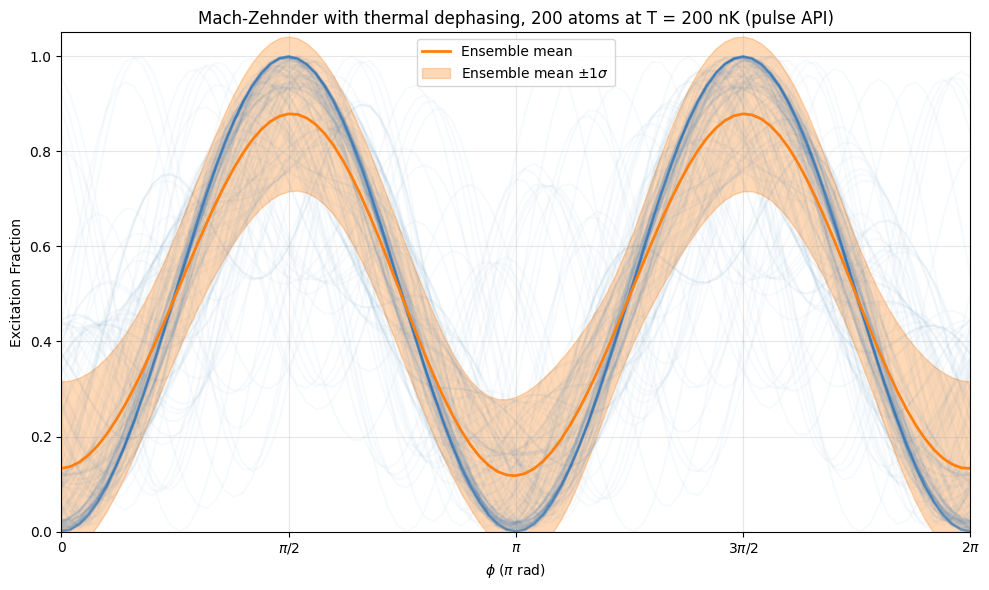

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual traces with low alpha
for curve in excitation_curves:
    ax.plot(phi_values / np.pi, curve, color="tab:blue", alpha=0.03)

# Plot mean and std
ax.plot(
    phi_values / np.pi,
    mean_excitation,
    color="tab:orange",
    lw=2,
    label="Ensemble mean",
)
ax.fill_between(
    phi_values / np.pi,
    mean_excitation - std_excitation,
    mean_excitation + std_excitation,
    color="tab:orange",
    alpha=0.3,
    label=r"Ensemble mean $\pm 1\sigma$",
)

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Excitation Fraction")
ax.set_title(
    f"Mach-Zehnder with thermal dephasing, {N_ATOMS} atoms at T = {TEMPERATURE*1e9:.0f} nK (pulse API)"
)
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
vs.tag_plot(small=True)
fig.tight_layout()

## Ensemble mean comparison

Run the same fixed-seed velocity ensemble through both the old low-level API and the new
pulse-sequence API and compare the resulting ensemble mean curves.
This is the meaningful test: any systematic difference between the two implementations
would survive the average and show up as a non-zero residual.

# Visualisations


## Simulated camera images

These synthetic camera images use the new event-based pulse-sequence API so each atom contributes weighted output branches with explicit final positions. The ground-state camera is read out immediately at the end of the sequence, while the excited-state camera is imaged after one additional 4 ms freefall.

The camera is displayed with $z$ vertical and $x$ horizontal. In this notebook the atoms start on-axis with no transverse velocity, so the horizontal extent is dominated by a lightweight synthetic point-spread function rather than real transverse cloud expansion.

The camera rendering is intentionally lightweight and easy to retune later. If the number of simulated atoms changes, the main knobs to update are the imaging phase, delay, z bins, x bins, and optional PSF width in the code cell below.

Rendering camera shot: 100%|██████████| 200/200 [00:00<00:00, 453.33it/s]


Camera phase: 0.93pi rad
Excited-state delay: 4.00 ms
z bins: 48, x pixels: 21
Ground image total weight: 170.1192
Excited image total weight: 29.8808
Approximate z pixel size: 2.890 um
Approximate x pixel size: 0.571 um


Text(0.5, 0.98, 'Synthetic dual-camera images for one shot at $\\phi = 0.93\\pi$')

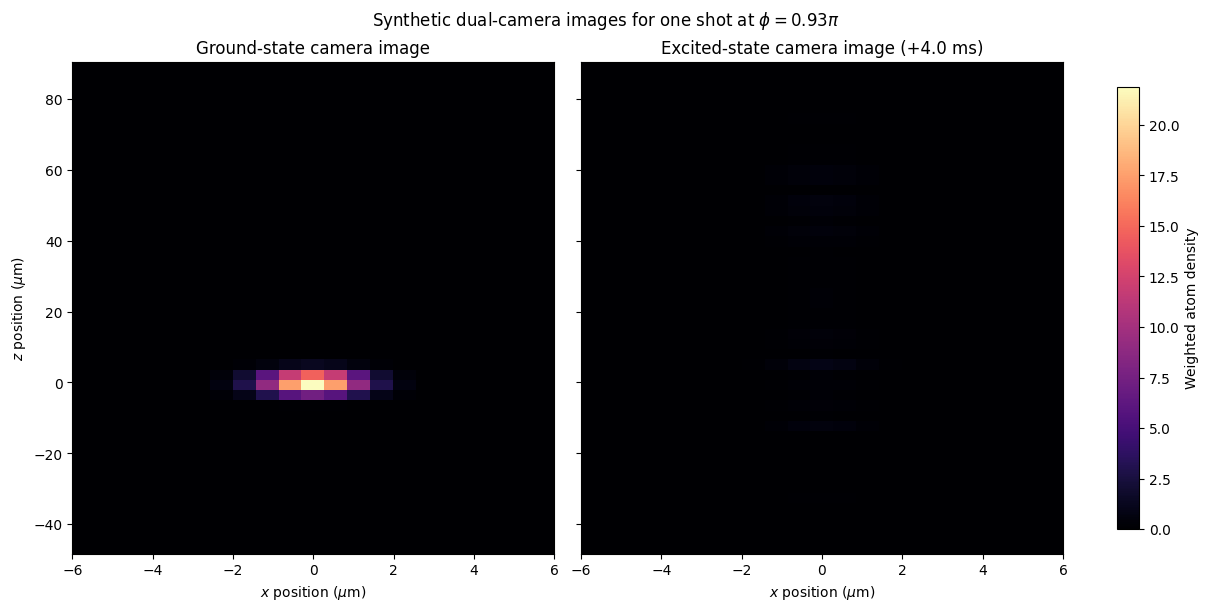

In [9]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from lmt_sim.lmt_sequence import (
    Freefall,
    build_mach_zehnder_pulse_sequence,
    run_pulse_sequence_in_lab_frame,
)
from lmt_sim.lmt_simulation import (
    RECOIL_FREQUENCY_HZ,
    RABI_FREQ,
    make_atom_states,
)

# Lightweight camera knobs: adjust these if N_ATOMS changes later.
CAMERA_PHASE = np.random.uniform(0, 2 * np.pi)
CAMERA_EXCITED_DELAY = 4e-3
CAMERA_Z_BINS = 48
CAMERA_X_PIXELS = 21
CAMERA_Z_PADDING_FRACTION = 0.15
CAMERA_X_PADDING_FRACTION = 0.25
CAMERA_X_MIN_HALF_RANGE_UM = 6.0
CAMERA_PSF_SIGMA_PIXELS = 1.5


def simulate_mz_final_state_pulse_api(
    phi,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    """Return the final AtomState for one atom using the pulse-sequence API."""
    pulse_sequence = build_mach_zehnder_pulse_sequence(
        phi=phi,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=time_between_pulses,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )

    initial_state = make_atom_states(
        initial_velocity_z=initial_velocity_z,
        c0=1,
        c1=0,
    )

    result = run_pulse_sequence_in_lab_frame(
        initial_state,
        pulse_sequence,
        initial_velocity_z=initial_velocity_z,
    )

    if result is None:
        raise RuntimeError("Mach-Zehnder sequence unexpectedly cleared the atom")

    state, _, _ = result
    return state


def apply_freefall_delay_with_pulse_api(state, initial_velocity_z, delay):
    """Apply an additional imaging delay using the pulse-sequence API."""
    sequence_logger = logging.getLogger("lmt_sim.lmt_sequence")
    old_level = sequence_logger.level
    sequence_logger.setLevel(logging.ERROR)
    try:
        result = run_pulse_sequence_in_lab_frame(
            state,
            [Freefall(duration=delay, label="camera_delay")],
            initial_velocity_z=initial_velocity_z,
        )
    finally:
        sequence_logger.setLevel(old_level)

    if result is None:
        raise RuntimeError("Pure freefall sequence unexpectedly removed the atom")

    delayed_state, _, _ = result
    return delayed_state


def compress_output_channels(state, want_ground):
    """Coherently combine rows with the same final (m, internal state)."""
    channel_rows = []
    mask_state = state.internal_is_ground if want_ground else ~state.internal_is_ground
    unique_m = np.unique(state.m_values[mask_state])

    for m in unique_m:
        mask = mask_state & (state.m_values == m)
        total_amp = np.sum(state.amplitudes[mask])
        weight = np.abs(total_amp) ** 2
        if weight == 0:
            continue
        first = np.flatnonzero(mask)[0]
        channel_rows.append(
            {
                "m": int(m),
                "x": float(state.positions[first, 0]),
                "z": float(state.positions[first, 2]),
                "weight": float(weight),
            }
        )

    return channel_rows


def make_camera_image(
    x_positions, weights, z_positions, x_edges, z_edges, psf_sigma_pixels
):
    image = np.zeros((len(z_edges) - 1, len(x_edges) - 1))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    x_pixel_size = np.diff(x_edges).mean()
    sigma_x = max(psf_sigma_pixels * x_pixel_size, 1e-12)

    for x, z, weight in zip(x_positions, z_positions, weights):
        z_index = np.searchsorted(z_edges, z, side="right") - 1
        if z_index < 0 or z_index >= image.shape[0]:
            continue
        x_profile = np.exp(-0.5 * ((x_centers - x) / sigma_x) ** 2)
        x_profile /= x_profile.sum()
        image[z_index, :] += weight * x_profile

    return image


ground_rows = []
excited_rows = []

for velocity in tqdm(velocities, desc="Rendering camera shot"):
    final_state = simulate_mz_final_state_pulse_api(
        CAMERA_PHASE,
        initial_velocity_z=velocity,
        time_between_pulses=T_FREE,
    )

    delayed_state = apply_freefall_delay_with_pulse_api(
        final_state,
        initial_velocity_z=velocity,
        delay=CAMERA_EXCITED_DELAY,
    )

    ground_rows.extend(compress_output_channels(final_state, want_ground=True))
    excited_rows.extend(compress_output_channels(delayed_state, want_ground=False))

all_x = np.array([row["x"] for row in ground_rows + excited_rows])
all_z = np.array([row["z"] for row in ground_rows + excited_rows])

x_span = np.ptp(all_x)
x_padding = max(CAMERA_X_PADDING_FRACTION * x_span, CAMERA_X_MIN_HALF_RANGE_UM * 1e-6)
x_edges = np.linspace(all_x.min() - x_padding, all_x.max() + x_padding, CAMERA_X_PIXELS + 1)

z_span = np.ptp(all_z)
if z_span == 0:
    z_span = 1e-6
z_padding = CAMERA_Z_PADDING_FRACTION * z_span
z_edges = np.linspace(all_z.min() - z_padding, all_z.max() + z_padding, CAMERA_Z_BINS + 1)

ground_image = make_camera_image(
    [row["x"] for row in ground_rows],
    [row["weight"] for row in ground_rows],
    [row["z"] for row in ground_rows],
    x_edges,
    z_edges,
    CAMERA_PSF_SIGMA_PIXELS,
)
excited_image = make_camera_image(
    [row["x"] for row in excited_rows],
    [row["weight"] for row in excited_rows],
    [row["z"] for row in excited_rows],
    x_edges,
    z_edges,
    CAMERA_PSF_SIGMA_PIXELS,
)

x_edges_um = 1e6 * x_edges
z_edges_um = 1e6 * z_edges
extent = [x_edges_um[0], x_edges_um[-1], z_edges_um[0], z_edges_um[-1]]
vmax = max(ground_image.max(), excited_image.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, constrained_layout=True)
images = [ground_image, excited_image]
titles = [
    "Ground-state camera image",
    f"Excited-state camera image (+{1e3 * CAMERA_EXCITED_DELAY:.1f} ms)",
]

for ax, image, title in zip(axes, images, titles):
    im = ax.imshow(
        image,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="magma",
        vmin=0.0,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel(r"$x$ position ($\mu$m)")

axes[0].set_ylabel(r"$z$ position ($\mu$m)")
cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("Weighted atom density")

print(f"Camera phase: {CAMERA_PHASE / np.pi:.2f}pi rad")
print(f"Excited-state delay: {1e3 * CAMERA_EXCITED_DELAY:.2f} ms")
print(f"z bins: {CAMERA_Z_BINS}, x pixels: {CAMERA_X_PIXELS}")
print(f"Ground image total weight: {sum(row['weight'] for row in ground_rows):.4f}")
print(f"Excited image total weight: {sum(row['weight'] for row in excited_rows):.4f}")
print(f"Approximate z pixel size: {np.diff(z_edges_um).mean():.3f} um")
print(f"Approximate x pixel size: {np.diff(x_edges_um).mean():.3f} um")

fig.suptitle(
    f"Synthetic dual-camera images for one shot at $\\phi = {CAMERA_PHASE / np.pi:.2f}\\pi$",
)